# **Aim**

The aim of this project is to build a robust retail demand forecasting system using historical sales data. The project focuses on predicting weekly sales for Walmart stores using machine learning and time series models such as XGBoost, LSTM, and Prophet.

----

The **goal** is to:

* Analyze sales patterns and seasonality
* Understand the impact of holidays and external factors
* Build predictive models for accurate sales forecasting
* Provide actionable business insights for retail decision-making

---

### **Dataset Description**

The dataset contains historical weekly sales data from Walmart stores along with additional features that influence demand.

### Files Included:

* **train.csv** → Historical weekly sales data
* **stores.csv** → Store metadata
* **features.csv** → External factors like temperature, fuel price, CPI, unemployment

---

In [67]:
# Install required libraries
!pip install prophet xgboost --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

from xgboost import XGBRegressor
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


## **1. Data Loading and Merging**

In this step, we:
- Upload dataset files
- Load train, features, and stores data
- Merge them into a single dataframe
- Inspect structure and basic information

In [2]:
from google.colab import files

# Upload files manually
uploaded = files.upload()

# Load datasets
train = pd.read_csv("train.csv", parse_dates=["Date"])
features = pd.read_csv("features.csv", parse_dates=["Date"])
stores = pd.read_csv("stores.csv")

# Merge datasets
df = train.merge(features, on=["Store", "Date"], how="left")
df = df.merge(stores, on="Store", how="left")

# Basic inspection
print("Shape of merged dataframe:", df.shape)
print("\nColumns:\n", df.columns)

df.head()

Saving features.csv to features.csv
Saving stores.csv to stores.csv
Saving train.csv to train.csv
Shape of merged dataframe: (421570, 17)

Columns:
 Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='object')


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## **2. Data Cleaning**

In this step, we handle missing values and prepare the dataset for analysis.

Key actions:
- Fill missing values in MarkDown columns with 0
- Handle missing numerical features (CPI, Unemployment, Temperature)
- Convert IsHoliday to integer format
- Check for any remaining null values

In [3]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values before cleaning:\n")
print(missing[missing > 0])

Missing values before cleaning:

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64


In [4]:
# Fill MarkDown columns with 0
markdown_cols = [col for col in df.columns if "MarkDown" in col]
df[markdown_cols] = df[markdown_cols].fillna(0)

In [5]:
# Fill numerical columns with median
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [7]:
# Keep one IsHoliday column (they are usually identical)
df["IsHoliday"] = df["IsHoliday_x"]

# Drop duplicates
df.drop(["IsHoliday_x", "IsHoliday_y"], axis=1, inplace=True)

# Convert to integer
df["IsHoliday"] = df["IsHoliday"].astype(int)

# Verify
print(df.columns)
df.head()

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'IsHoliday'],
      dtype='object')


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,IsHoliday
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,0
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,1
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,0
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,0
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,0


In [8]:
# Final check
print("\nMissing values after cleaning:\n")
print(df.isnull().sum().sum())


Missing values after cleaning:

0


## **3. Exploratory Data Analysis (EDA)**

In this section, we analyze patterns in sales data.

We will:
- Examine overall sales trends over time
- Compare sales across store types
- Analyze the impact of holidays
- Identify top-performing departments
- Study feature correlations
- Perform seasonal decomposition for time series understanding

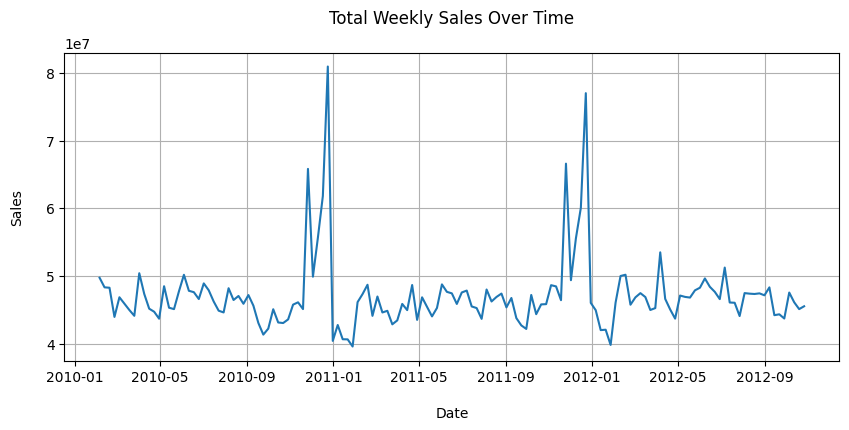

In [11]:
# Aggregate total weekly sales over time
sales_trend = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(10,4))
plt.plot(sales_trend)
plt.title("Total Weekly Sales Over Time\n")
plt.xlabel("\nDate")
plt.ylabel("Sales\n")
plt.grid()
plt.show()

### **Sales by Store Type**

We compare average sales across different store types (A, B, C).

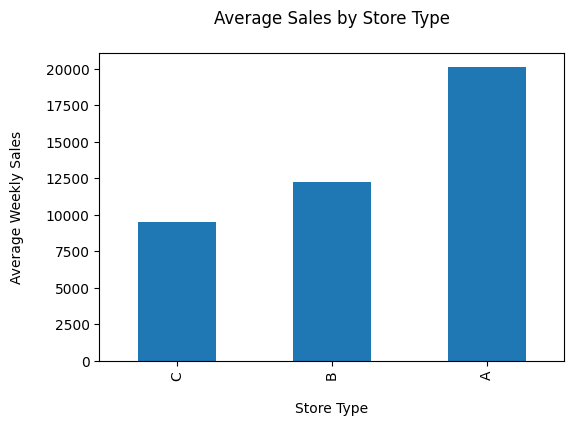

In [12]:
store_type_sales = df.groupby("Type")["Weekly_Sales"].mean().sort_values()

plt.figure(figsize=(6,4))
store_type_sales.plot(kind="bar")
plt.title("Average Sales by Store Type\n")
plt.xlabel("\nStore Type")
plt.ylabel("Average Weekly Sales\n")
plt.show()

### **Holiday Impact on Sales**

We analyze how holidays affect weekly sales.

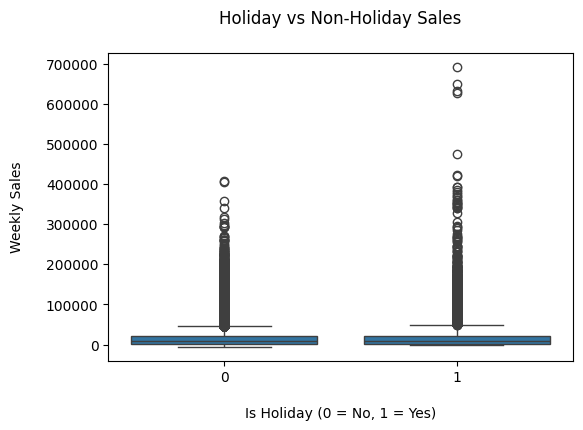

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs Non-Holiday Sales\n")
plt.xlabel("\nIs Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales\n")
plt.show()

### **Top Departments by Sales**

Identify departments generating the highest average sales.

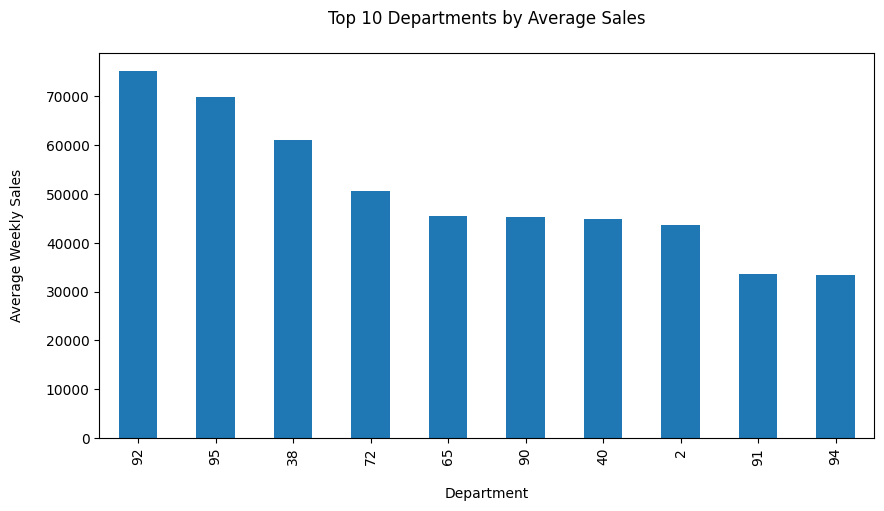

In [14]:
top_depts = df.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_depts.plot(kind="bar")
plt.title("Top 10 Departments by Average Sales\n")
plt.xlabel("\nDepartment")
plt.ylabel("Average Weekly Sales\n")
plt.show()

### **Correlation Heatmap**

Understanding relationships between numerical features.

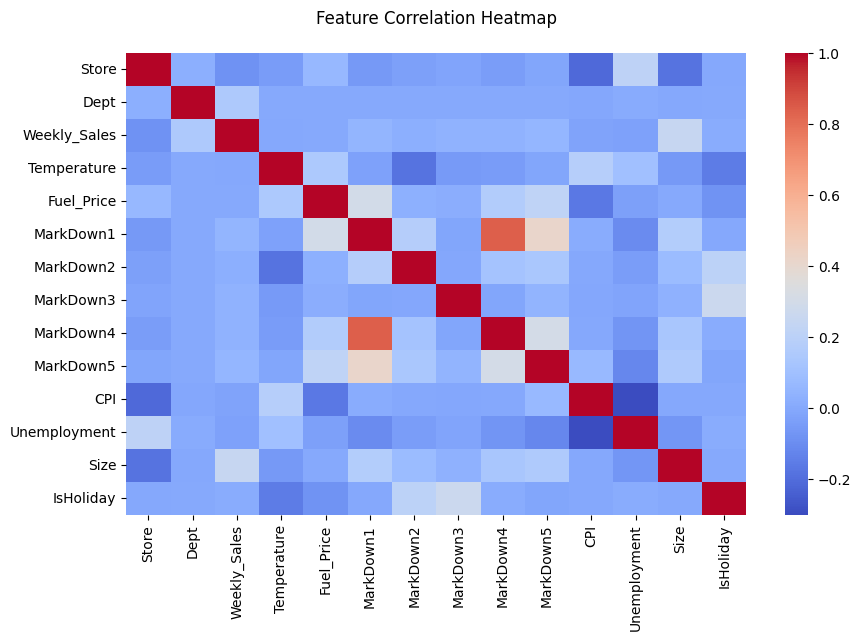

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap\n")
plt.show()

### **Seasonal Decomposition**

We analyze trend, seasonality, and residuals for a single store and department.

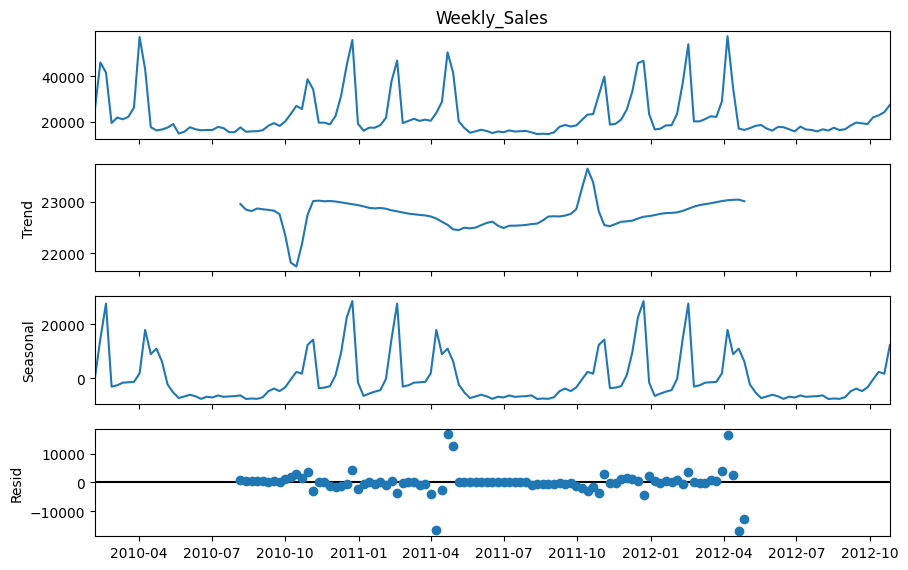

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Filter one store + dept
ts = df[(df["Store"] == 1) & (df["Dept"] == 1)]
ts = ts.sort_values("Date")

ts_series = ts.set_index("Date")["Weekly_Sales"]

# Decompose
result = seasonal_decompose(ts_series, model="additive", period=52)

# Increase figure size
fig = result.plot()
fig.set_size_inches(10, 6)

plt.show()

## **4.Feature Engineering**

In this step, we create meaningful features to improve model performance.

We will:
- Extract date-based features
- Create lag features (previous weeks sales)
- Create rolling mean features
- Encode categorical variables
- Prepare dataset for modeling

In [24]:
# Extract date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfYear"] = df["Date"].dt.dayofyear

df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Unemployment,Type,Size,IsHoliday,Year,Month,Week,DayOfYear,IsMonthStart,IsMonthEnd
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,...,8.106,A,151315,0,2010,2,5,36,0,0
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,...,8.106,A,151315,1,2010,2,6,43,0,0
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,...,8.106,A,151315,0,2010,2,7,50,0,0
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,...,8.106,A,151315,0,2010,2,8,57,0,0
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,8.106,A,151315,0,2010,3,9,64,0,0


### **Lag Features**

Lag features help the model learn from past sales patterns.

In [25]:
# Sort for correct lag creation
df = df.sort_values(["Store", "Dept", "Date"])

# Create lag features
df["lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df["lag_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)
df["lag_12"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(12)

### **Rolling Mean Features**

Rolling averages smooth out fluctuations and capture trends.

In [26]:
df["rolling_mean_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(4).mean())

df["rolling_mean_12"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(12).mean())

### **Encoding Categorical Features**

We convert categorical variables into numerical form for modeling.

In [27]:
le = LabelEncoder()

df["Type"] = le.fit_transform(df["Type"])

### **Final Dataset Preparation**

We remove rows with missing values caused by lag features.

In [28]:
df_model = df.dropna().copy()

print("Final dataset shape:", df_model.shape)
df_model.head()

Final dataset shape: (382955, 27)


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Month,Week,DayOfYear,IsMonthStart,IsMonthEnd,lag_1,lag_4,lag_12,rolling_mean_4,rolling_mean_12
12,1,1,2010-04-30,16555.11,67.41,2.780,0.0,0.0,0.0,0.0,...,4,17,120,0,1,16145.35,57258.43,24924.50,33490.4125,29763.489167
13,1,1,2010-05-07,17413.94,72.55,2.835,0.0,0.0,0.0,0.0,...,5,18,127,0,0,16555.11,42960.91,46039.49,23314.5825,29066.040000
14,1,1,2010-05-14,18926.74,74.78,2.854,0.0,0.0,0.0,0.0,...,5,19,134,0,0,17413.94,17596.96,41595.55,16927.8400,26680.577500
15,1,1,2010-05-21,14773.04,76.44,2.826,0.0,0.0,0.0,0.0,...,5,20,141,0,0,18926.74,16145.35,19403.54,17260.2850,24791.510000
16,1,1,2010-05-28,15580.43,80.44,2.759,0.0,0.0,0.0,0.0,...,5,21,148,0,0,14773.04,16555.11,21827.90,16917.2075,24405.635000


## **Model 1 — Prophet Forecasting**

We use Prophet for time series forecasting on a single Store and Department.

Steps:
- Filter Store 1 and Dept 1
- Prepare data in Prophet format (ds, y)
- Add external regressors
- Train model on 80 percent data
- Forecast on remaining 20 percent
- Evaluate using RMSE and MAPE

In [29]:
# Filter single time series
prophet_df = df[(df["Store"] == 1) & (df["Dept"] == 1)].copy()
prophet_df = prophet_df.sort_values("Date")

# Select relevant columns
prophet_df = prophet_df[["Date", "Weekly_Sales", "IsHoliday", "Temperature", "CPI"]]

# Rename for Prophet
prophet_df.rename(columns={"Date": "ds", "Weekly_Sales": "y"}, inplace=True)

# Train-test split (80-20)
split_idx = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:split_idx]
test_prophet = prophet_df.iloc[split_idx:]

print(train_prophet.shape, test_prophet.shape)
train_prophet.head()

(114, 5) (29, 5)


,ds,y,IsHoliday,Temperature,CPI
0,2010-02-05,24924.50,0,42.31,211.096358
1,2010-02-12,46039.49,1,38.51,211.242170
2,2010-02-19,41595.55,0,39.93,211.289143
3,2010-02-26,19403.54,0,46.63,211.319643
4,2010-03-05,21827.90,0,46.50,211.350143


In [30]:
## Training Prophet Model with Regressors

model = Prophet()

# Add regressors
model.add_regressor("IsHoliday")
model.add_regressor("Temperature")
model.add_regressor("CPI")

# Train model
model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [32]:
## Forecasting and Evaluation
# Prepare future dataframe (test set)
future = test_prophet[["ds", "IsHoliday", "Temperature", "CPI"]]

forecast = model.predict(future)

# Merge predictions
results = test_prophet.copy()
results["yhat"] = forecast["yhat"].values

# Evaluation
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))
mape = mean_absolute_percentage_error(results["y"], results["yhat"])

print("Prophet RMSE:", rmse)
print("\nProphet MAPE:", mape)

Prophet RMSE: 4170.248462832174

Prophet MAPE: 0.12771517560818632


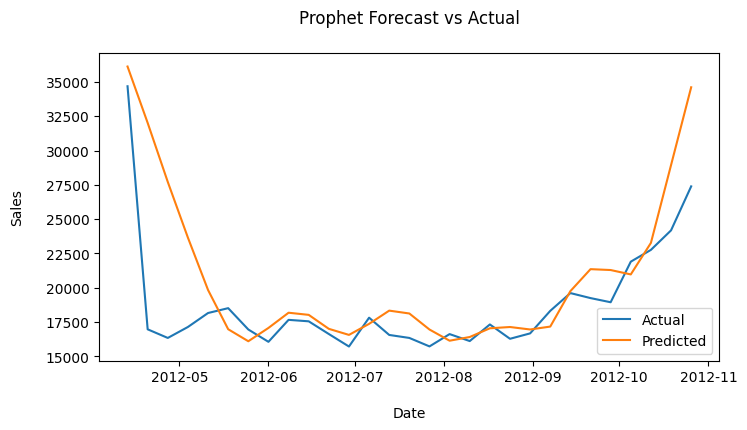

In [35]:
## Forecast Visualization

plt.figure(figsize=(8,4))
plt.plot(results["ds"], results["y"], label="Actual")
plt.plot(results["ds"], results["yhat"], label="Predicted")
plt.title("Prophet Forecast vs Actual\n")
plt.xlabel("\nDate")
plt.ylabel("Sales\n")
plt.legend()
plt.show()

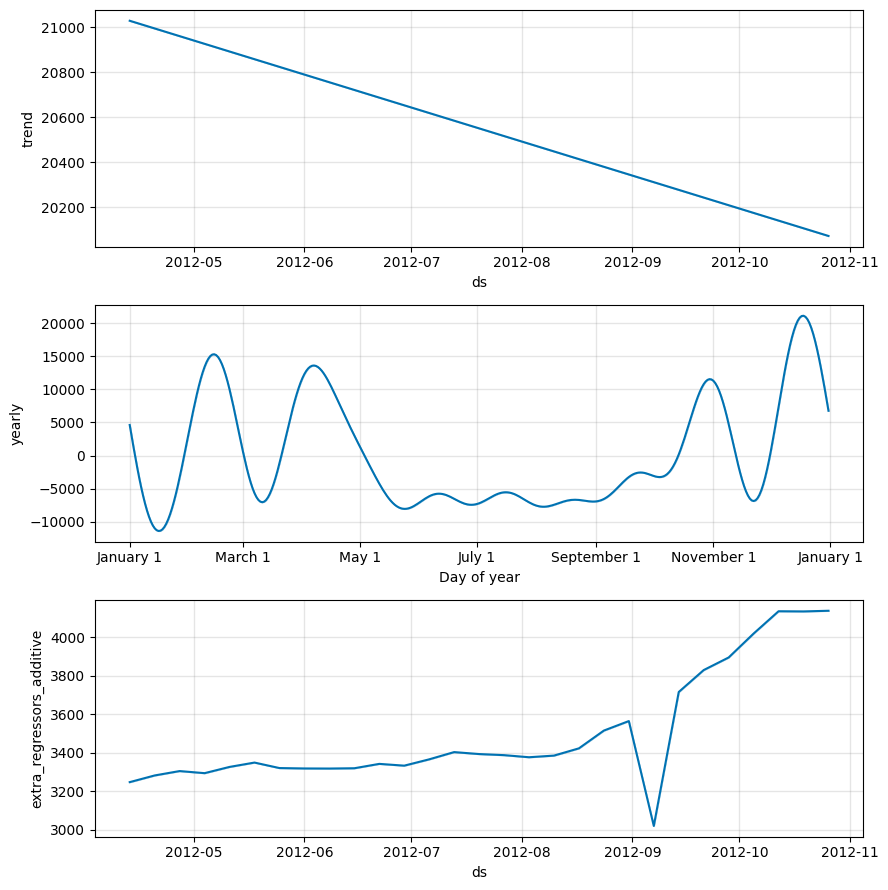

In [36]:
model.plot_components(forecast)
plt.show()

## **Model 2 — XGBoost Regressor**

We use XGBoost to model sales across all stores and departments.

Steps:
- Use full engineered dataset
- Perform time-based train-test split
- Train XGBoost model
- Evaluate using RMSE and MAPE
- Analyze feature importance

In [37]:
# Sort by date
df_model = df_model.sort_values("Date")

# Define test period (last 8 weeks)
split_date = df_model["Date"].max() - pd.Timedelta(weeks=8)

train_xgb = df_model[df_model["Date"] < split_date]
test_xgb  = df_model[df_model["Date"] >= split_date]

print("Train shape:", train_xgb.shape)
print("Test shape:", test_xgb.shape)

Train shape: (356328, 27)
Test shape: (26627, 27)


In [62]:
## Feature and Target Selection

feature_cols = [
    "Store", "Dept", "Temperature", "Fuel_Price",
    "CPI", "Unemployment", "Type", "Size",
    "IsHoliday", "Year", "Month", "Week",
    "lag_1", "lag_4", "lag_12",
    "rolling_mean_4", "rolling_mean_12"
]

X_train = train_xgb[feature_cols ]
y_train = train_xgb["Weekly_Sales"]

X_test = test_xgb[feature_cols ]
y_test = test_xgb["Weekly_Sales"]

In [63]:
## Training XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [64]:
## Model Evaluation

y_pred = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mape_xgb = mean_absolute_percentage_error(y_test, y_pred)

mask = y_test != 0

mape_xgb = mean_absolute_percentage_error(
    y_test[mask],
    y_pred[mask]
)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost RMSE: 2839.71384648017
XGBoost MAPE: 2.7713217288814747


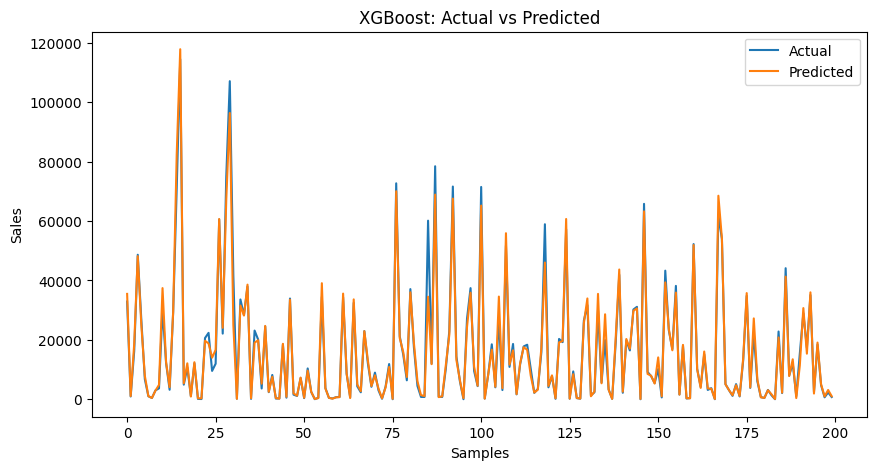

In [65]:
## Actual vs Predicted

plt.figure(figsize=(10,5))

sample = 200  # plot subset for clarity
plt.plot(y_test.values[:sample], label="Actual")
plt.plot(y_pred[:sample], label="Predicted")

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

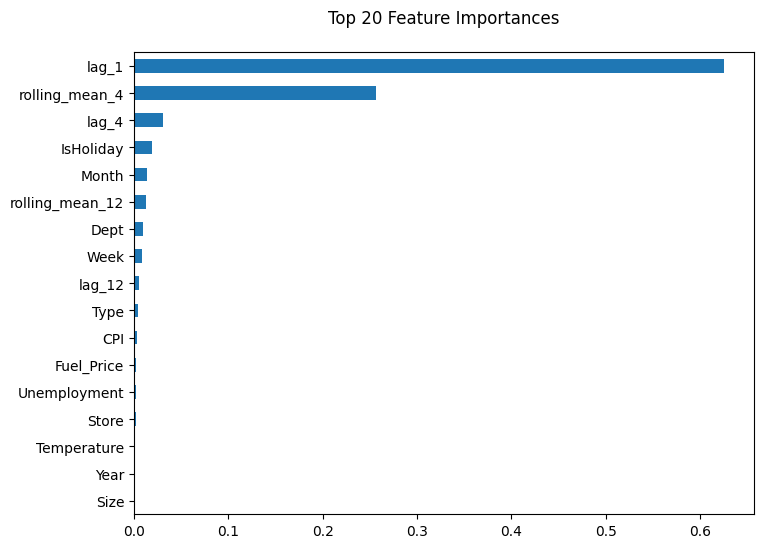

In [77]:
## Feature Importance

importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.title("Top 20 Feature Importances\n")
plt.gca().invert_yaxis()
plt.show()

## **Model 3 — LSTM (Deep Learning)**

We use an LSTM model to capture temporal dependencies in sales data.

Steps:
- Use a single time series (Store 1, Dept 1)
- Normalize data
- Create sequences (window = 12 weeks)
- Train LSTM model
- Evaluate performance

In [50]:
from sklearn.preprocessing import MinMaxScaler

# Filter single series
lstm_df = df[(df["Store"] == 1) & (df["Dept"] == 1)].copy()
lstm_df = lstm_df.sort_values("Date")

data = lstm_df["Weekly_Sales"].values.reshape(-1, 1)

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print("Data shape:", data_scaled.shape)

Data shape: (143, 1)


In [51]:
## Creating Sequences

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 12

X_lstm, y_lstm = create_sequences(data_scaled, window_size)

print(X_lstm.shape, y_lstm.shape)

(131, 12, 1) (131, 1)


In [52]:
## Train-Test Split

split = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split]
X_test_lstm  = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm  = y_lstm[split:]

In [53]:
## Building LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
## Training LSTM Model

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=16,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0704 - val_loss: 0.0110
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0538 - val_loss: 0.0197
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0540 - val_loss: 0.0168
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0550 - val_loss: 0.0129
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0556 - val_loss: 0.0085
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0534 - val_loss: 0.0125
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0549 - val_loss: 0.0129
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0510 - val_loss: 0.0111
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0533 - val_loss: 0.0120
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0539 - val_loss: 0.0130
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0501 - val_loss: 0.0134
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0524 - val_loss: 0.0153
E

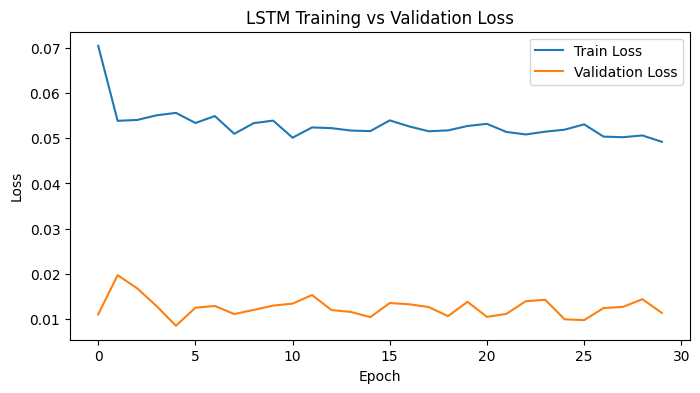

In [55]:
## Training vs Validation Loss

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [56]:
## LSTM Evaluation

# Predictions
y_pred_lstm = model_lstm.predict(X_test_lstm)

# Inverse transform
y_test_actual = scaler.inverse_transform(y_test_lstm)
y_pred_actual = scaler.inverse_transform(y_pred_lstm)

# Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

mask = y_test_actual != 0
mape_lstm = mean_absolute_percentage_error(
    y_test_actual[mask],
    y_pred_actual[mask]
)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
LSTM RMSE: 4588.8761078901325
LSTM MAPE: 0.23042721245654724


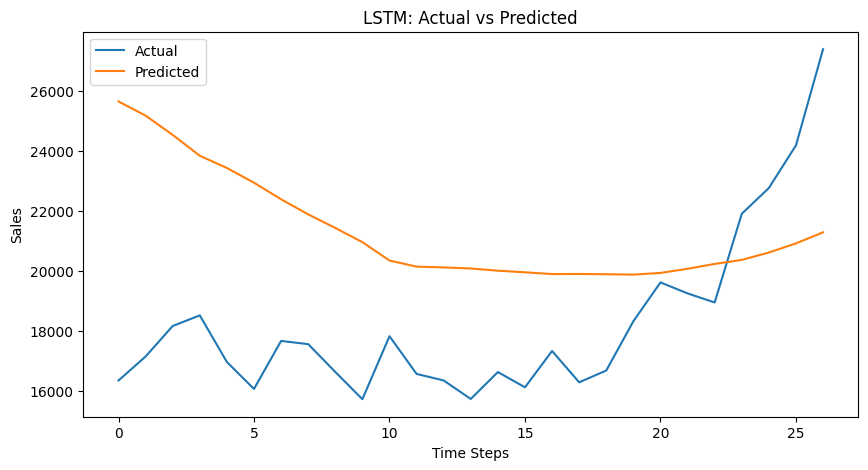

In [68]:
## LSTM Predictions vs Actual

plt.figure(figsize=(10,5))

n = min(100, len(y_test_actual))
plt.plot(y_test_actual[:n], label="Actual")
plt.plot(y_pred_actual[:n], label="Predicted")

plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [72]:
results_df = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost', 'LSTM'],
    'RMSE': [round(rmse, 2), round(rmse_xgb, 2), round(rmse_lstm, 2)],
    'MAPE': [round(mape, 4), round(mape_xgb, 4), round(mape_lstm, 4)]
})
print(results_df.to_string(index=False))

  Model    RMSE   MAPE
Prophet 4170.25 0.1277
XGBoost 2839.71 2.7713
   LSTM 4588.88 0.2304


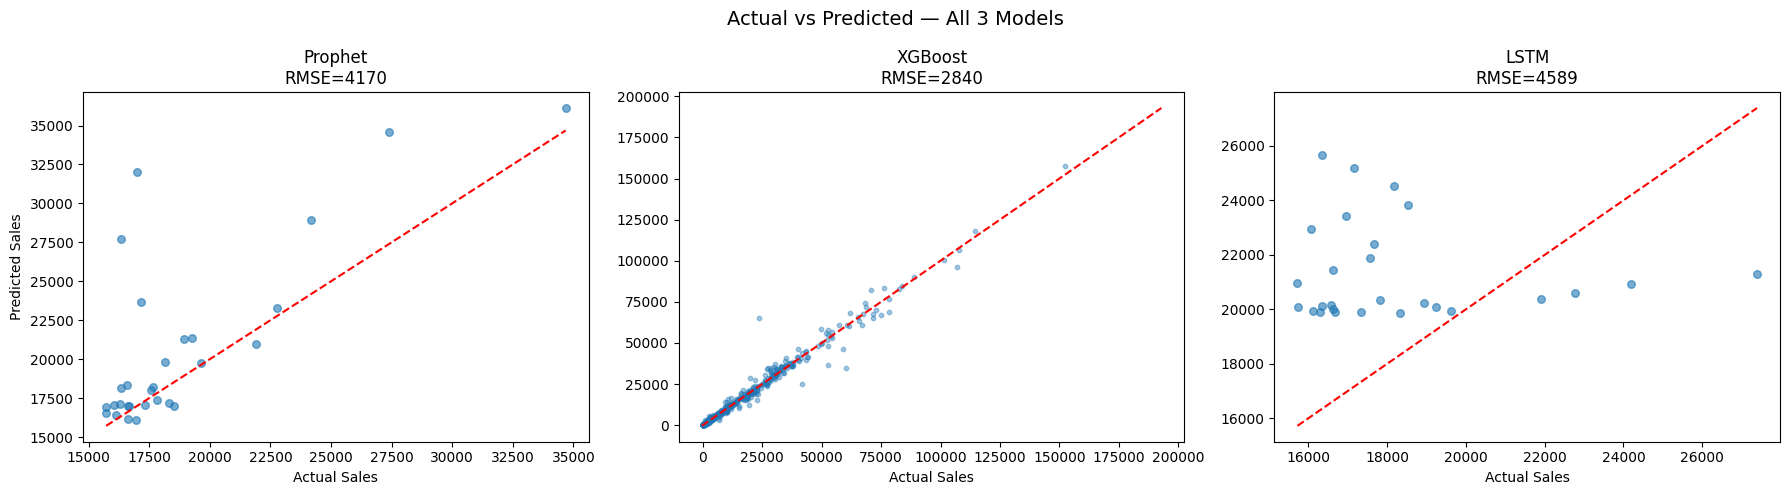

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prophet
axes[0].scatter(results['y'], results['yhat'], alpha=0.6, s=30)
axes[0].plot([results['y'].min(), results['y'].max()],
             [results['y'].min(), results['y'].max()], 'r--')
axes[0].set_title(f'Prophet\nRMSE={rmse:.0f}')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')

# XGBoost
axes[1].scatter(y_test.values[:500], y_pred[:500], alpha=0.4, s=10)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'XGBoost\nRMSE={rmse_xgb:.0f}')
axes[1].set_xlabel('Actual Sales')

# LSTM
axes[2].scatter(y_test_actual, y_pred_actual, alpha=0.6, s=30)
axes[2].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()], 'r--')
axes[2].set_title(f'LSTM\nRMSE={rmse_lstm:.0f}')
axes[2].set_xlabel('Actual Sales')

plt.suptitle('Actual vs Predicted — All 3 Models', fontsize=14)
plt.tight_layout()
plt.show()

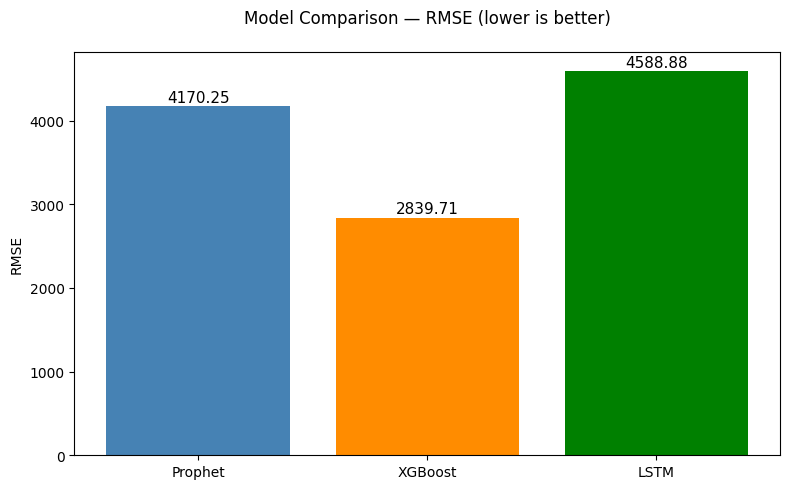

In [76]:
plt.figure(figsize=(8,5))
bars = plt.bar(results_df['Model'], results_df['RMSE'],
               color=['steelblue', 'darkorange', 'green'])
plt.title('Model Comparison — RMSE (lower is better)\n')
plt.ylabel('RMSE')

for bar, val in zip(bars, results_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.show()



### **Key Observations**

- XGBoost achieved the lowest RMSE, indicating best overall prediction accuracy
- Prophet performed best in terms of percentage error (MAPE)
- LSTM struggled due to limited data and high variability in sales

### **Model Suitability**

- Prophet: Best for single time series and interpretability
- XGBoost: Best for large-scale retail forecasting across stores
- LSTM: Useful for deep temporal patterns but requires more data

---

## **Business Insights**

### Sales Patterns
- Sales show strong seasonality across weeks
- Certain periods (holiday seasons) show spikes in demand

----

### Holiday Impact
- Sales tend to increase during holiday weeks
- Promotions and markdowns significantly influence demand

---

### Store Differences
- Store type and size affect sales volume
- Larger stores generate higher average sales

---

### Business Applications

This forecasting system can help:

- Inventory Management  
  Ensure optimal stock levels and reduce overstocking

- Staff Scheduling  
  Allocate workforce based on predicted demand

- Promotion Planning  
  Identify high-demand periods for targeted marketing

  -----

### Limitations

- No SKU-level granularity
- External events (festivals, COVID, etc.) not included
- Some missing promotional data

---

### Future Improvements

- Use ensemble models (XGBoost + Prophet)
- Add external APIs (weather, events)
- Train separate models per store or department

-----